## **Import libraries, data and Preprocessing**

In [4]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model

In [5]:
data = pd.read_csv('combined_data.csv')

In [6]:
data.head()

,PDB,chain_id,resSeq,pos,aa,ss,CAx,CAy,CAz,Nx,...,hbE,hbH,cis,phi,psi,omega,lambda,sin_lambda,cos_lambda,lambda_valid
0,1amt,A,1,0,X,C,46.920,3.266,-2.573,48.065,...,0.0,2.0,0,NaN,2.340097,0.077324,NaN,NaN,NaN,0
1,1amt,A,2,1,P,H,44.970,0.437,-4.396,46.136,...,0.0,1.0,0,2.076612,2.566800,0.061647,0.830539,0.738295,0.674478,1
2,1amt,A,3,2,X,H,43.781,-1.151,-1.108,44.584,...,0.0,1.0,0,1.995495,2.266631,0.020281,0.911196,0.790237,0.612801,1
3,1amt,A,4,3,A,H,42.065,2.185,-0.170,43.076,...,0.0,2.0,0,2.153327,2.282802,0.024743,0.995800,0.839194,0.543832,1
4,1amt,A,5,4,X,H,40.420,2.596,-3.610,41.335,...,0.0,2.0,0,2.052216,2.370488,0.032921,1.136675,0.907240,0.420613,1


In [7]:
data.shape

(1469317, 38)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469317 entries, 0 to 1469316
Data columns (total 38 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   PDB           1469317 non-null  object 
 1   chain_id      1469317 non-null  object 
 2   resSeq        1469317 non-null  int64  
 3   pos           1469317 non-null  int64  
 4   aa            1469317 non-null  object 
 5   ss            1469317 non-null  object 
 6   CAx           1469317 non-null  float64
 7   CAy           1469317 non-null  float64
 8   CAz           1469317 non-null  float64
 9   Nx            1469317 non-null  float64
 10  Ny            1469317 non-null  float64
 11  Nz            1469317 non-null  float64
 12  Cx            1469317 non-null  float64
 13  Cy            1469317 non-null  float64
 14  Cz            1469317 non-null  float64
 15  Ox            1469317 non-null  float64
 16  Oy            1469317 non-null  float64
 17  Oz            1469317 non-n

In [9]:
data.isnull().sum()

PDB                 0
chain_id            0
resSeq              0
pos                 0
aa                  0
ss                  0
CAx                 0
CAy                 0
CAz                 0
Nx                  0
Ny                  0
Nz                  0
Cx                  0
Cy                  0
Cz                  0
Ox                  0
Oy                  0
Oz                  0
r13b                0
r13f                0
r14b                0
r14f                0
r15b                0
r15f                0
n4                  0
n45                 0
n5                  0
n6                  0
hbE                 0
hbH                 0
cis                 0
phi              6526
psi              6526
omega            6526
lambda          13052
sin_lambda      13052
cos_lambda      13052
lambda_valid        0
dtype: int64

In [10]:
data.describe()

,resSeq,pos,CAx,CAy,CAz,Nx,Ny,Nz,Cx,Cy,...,hbE,hbH,cis,phi,psi,omega,lambda,sin_lambda,cos_lambda,lambda_valid
count,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,...,1.469317e+06,1.469317e+06,1.469317e+06,1.462791e+06,1.462791e+06,1.462791e+06,1.456265e+06,1.456265e+06,1.456265e+06,1.469317e+06
mean,2.173436e+02,1.516659e+02,1.435691e+01,1.639416e+01,1.909262e+01,1.435639e+01,1.639353e+01,1.909313e+01,1.435741e+01,1.639466e+01,...,4.919837e-01,9.718522e-01,3.054480e-03,1.403237e+00,6.366498e-01,-1.328296e-02,-4.704359e-01,-3.708825e-02,1.940177e-01,9.911170e-01
std,2.350211e+02,1.284606e+02,3.290956e+01,3.347418e+01,3.672096e+01,3.289029e+01,3.345574e+01,3.670350e+01,3.290100e+01,3.346514e+01,...,7.876328e-01,8.355606e-01,5.518290e-02,9.674205e-01,1.892956e+00,2.075279e-01,1.450251e+00,7.624975e-01,6.161004e-01,9.383036e-02
min,-2.600000e+01,0.000000e+00,-6.440840e+02,-3.424560e+02,-2.905270e+02,-6.428870e+02,-3.422690e+02,-2.904290e+02,-6.437890e+02,-3.415240e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.140929e+00,-3.141592e+00,-3.141581e+00,-3.141547e+00,-1.000000e+00,-1.000000e+00,0.000000e+00
25%,7.800000e+01,5.600000e+01,-2.823000e+00,-2.988000e+00,-9.030000e-01,-2.803000e+00,-2.978000e+00,-8.960000e-01,-2.820000e+00,-2.976000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.097184e+00,-8.254282e-01,-6.588644e-02,-1.944046e+00,-8.590904e-01,-3.967725e-01,1.000000e+00
50%,1.570000e+02,1.200000e+02,1.283600e+01,1.295300e+01,1.462700e+01,1.282900e+01,1.294100e+01,1.462300e+01,1.283700e+01,1.295500e+01,...,0.000000e+00,1.000000e+00,0.000000e+00,1.757371e+00,-1.171372e-01,-1.115822e-02,9.542998e-02,7.986035e-02,5.197937e-01,1.000000e+00
75%,2.760000e+02,2.140000e+02,2.944700e+01,3.167200e+01,3.271100e+01,2.942400e+01,3.164900e+01,3.267600e+01,2.944700e+01,3.166900e+01,...,1.000000e+00,2.000000e+00,0.000000e+00,2.027746e+00,2.451379e+00,4.012272e-02,8.976969e-01,7.744298e-01,6.770621e-01,1.000000e+00
max,3.671000e+03,1.287000e+03,3.361940e+02,4.142510e+02,5.024780e+02,3.370780e+02,4.139000e+02,5.019180e+02,3.355160e+02,4.144690e+02,...,4.000000e+00,4.000000e+00,1.000000e+00,3.139893e+00,3.141592e+00,3.141572e+00,3.141579e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [11]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns (float + int):")
print(numeric_cols)
numeric_data = data[numeric_cols]
numeric_data = numeric_data.fillna(numeric_data.mean())

Numeric columns (float + int):
Index(['resSeq', 'pos', 'CAx', 'CAy', 'CAz', 'Nx', 'Ny', 'Nz', 'Cx', 'Cy',
       'Cz', 'Ox', 'Oy', 'Oz', 'r13b', 'r13f', 'r14b', 'r14f', 'r15b', 'r15f',
       'n4', 'n45', 'n5', 'n6', 'hbE', 'hbH', 'cis', 'phi', 'psi', 'omega',
       'lambda', 'sin_lambda', 'cos_lambda', 'lambda_valid'],
      dtype='object')


In [12]:
data = data.fillna(data.mode().iloc[0])
data.isnull().sum()

PDB             0
chain_id        0
resSeq          0
pos             0
aa              0
ss              0
CAx             0
CAy             0
CAz             0
Nx              0
Ny              0
Nz              0
Cx              0
Cy              0
Cz              0
Ox              0
Oy              0
Oz              0
r13b            0
r13f            0
r14b            0
r14f            0
r15b            0
r15f            0
n4              0
n45             0
n5              0
n6              0
hbE             0
hbH             0
cis             0
phi             0
psi             0
omega           0
lambda          0
sin_lambda      0
cos_lambda      0
lambda_valid    0
dtype: int64

In [13]:
# ----- Encode ss -----
ohe_ss = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ss_arr = ohe_ss.fit_transform(data[["ss"]].astype(str))
ss_cols = ohe_ss.get_feature_names_out(["ss"])
df_ss = pd.DataFrame(ss_arr, columns=ss_cols, index=data.index)

# ----- Encode aa -----
ohe_aa = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
aa_arr = ohe_aa.fit_transform(data[["aa"]].astype(str))
aa_cols = ohe_aa.get_feature_names_out(["aa"])
df_aa = pd.DataFrame(aa_arr, columns=aa_cols, index=data.index)

# ----- Build final dataframe -----
df = pd.concat([data.drop(columns=["ss", "aa"]), df_ss, df_aa], axis=1)

In [14]:
# -----------------------------
# 1. One-hot encode chain_id
# -----------------------------
ohe_chain = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
chain_arr = ohe_chain.fit_transform(df[["chain_id"]].astype(str))
chain_cols = ohe_chain.get_feature_names_out(["chain_id"])
df_chain = pd.DataFrame(chain_arr, columns=chain_cols, index=df.index)

# -----------------------------
# 2. Label-encode PDB column
# -----------------------------
le_pdb = LabelEncoder()
pdb_numeric = le_pdb.fit_transform(df["PDB"].astype(str))
df_pdb = pd.DataFrame({"PDB_numeric": pdb_numeric}, index=df.index)

# -----------------------------
# 3. Build final dataframe
# -----------------------------
df = pd.concat(
    [
        df.drop(columns=["chain_id", "PDB"]),
        df_chain,
        df_pdb
    ],
    axis=1
)

In [15]:
df.head()

,resSeq,pos,CAx,CAy,CAz,Nx,Ny,Nz,Cx,Cy,...,chain_id_O,chain_id_P,chain_id_R,chain_id_S,chain_id_U,chain_id_V,chain_id_X,chain_id_Y,chain_id_Z,PDB_numeric
0,1,0,46.920,3.266,-2.573,48.065,2.462,-1.964,45.865,2.301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
1,2,1,44.970,0.437,-4.396,46.136,1.294,-3.808,44.079,-0.162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
2,3,2,43.781,-1.151,-1.108,44.584,-0.501,-2.166,42.813,-0.016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
3,4,3,42.065,2.185,-0.170,43.076,1.102,-0.526,41.011,2.324,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
4,5,4,40.420,2.596,-3.610,41.335,2.427,-2.458,39.578,1.349,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11


In [16]:
target_columns = ["CAx", "CAy", "CAz", "Nx", "Ny", "Nz", "Cx", "Cy", "Cz", "Ox", "Oy", "Oz"]
y = df[target_columns]
X = df.drop(columns=target_columns)

In [17]:
def Preprocessing(X, Y, test_size=0.30, seed=0, shuffle=False):
    # Convert to float
    X = X.astype(float)
    Y = Y.astype(float)

    # -------------------------
    # Normalize X
    # -------------------------
    x_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_norm = x_scaler.fit_transform(X)

    # -------------------------
    # Normalize Y
    # -------------------------
    y_scaler = MinMaxScaler(feature_range=(-1, 1))
    Y_norm = y_scaler.fit_transform(Y)

    # -------------------------
    # Train/Test split ONLY
    # -------------------------
    x_train, x_test, y_train, y_test = train_test_split(
        X_norm, Y_norm,
        test_size=test_size,
        shuffle=shuffle,
        random_state=seed
    )

    # Shapes
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test, x_scaler, y_scaler

In [18]:
x_train, x_test, y_train, y_test, x_scaler, y_scaler = \
    Preprocessing(X, y, test_size=0.30, seed=0, shuffle=False)

x_train shape: (1028521, 82)
y_train shape: (1028521, 12)
x_test shape: (440796, 82)
y_test shape: (440796, 12)


## **Model (CNN Attention)**

In [19]:
import tensorflow as tf

def kabsch_align(pred, true):
    """
    pred, true: (batch, N, 3)
    Returns: aligned_pred (batch, N, 3)
    """
    pred_mean = tf.reduce_mean(pred, axis=1, keepdims=True)
    true_mean = tf.reduce_mean(true, axis=1, keepdims=True)

    pred_centered = pred - pred_mean
    true_centered = true - true_mean

    # Covariance: (B, 3, 3)
    cov = tf.matmul(pred_centered, true_centered, transpose_a=True)

    # SVD
    s, u, v = tf.linalg.svd(cov)  # u: (B,3,3), v: (B,3,3)

    # R0 = V * U^T
    u_t = tf.transpose(u, perm=[0, 2, 1])
    r0 = tf.matmul(v, u_t)  # (B,3,3)

    # ---- manual 3x3 determinant of r0 (XLA-safe) ----
    a = r0[:, 0, 0]
    b = r0[:, 0, 1]
    c = r0[:, 0, 2]
    d = r0[:, 1, 0]
    e = r0[:, 1, 1]
    f = r0[:, 1, 2]
    g = r0[:, 2, 0]
    h = r0[:, 2, 1]
    i = r0[:, 2, 2]

    det_r0 = (
        a * (e * i - f * h)
        - b * (d * i - f * g)
        + c * (d * h - e * g)
    )  # (B,)

    sign = tf.sign(det_r0)  # (B,)

    # D = diag(1, 1, sign)
    ones = tf.ones_like(sign)
    diag = tf.stack([ones, ones, sign], axis=-1)  # (B,3)
    dmat = tf.linalg.diag(diag)  # (B,3,3)

    # Proper rotation: R = V * D * U^T
    r = tf.matmul(v, tf.matmul(dmat, u_t))  # (B,3,3)

    aligned = tf.matmul(pred_centered, r) + true_mean  # (B,N,3)
    return aligned

In [20]:
def kabsch_crmsd(y_true, y_pred):
    batch = tf.shape(y_pred)[0]
    y_pred = tf.reshape(y_pred, (batch, -1, 3))
    y_true = tf.reshape(y_true, (batch, -1, 3))

    aligned = kabsch_align(y_pred, y_true)
    diff = aligned - y_true

    crmsd = tf.sqrt(tf.reduce_mean(tf.reduce_sum(tf.square(diff), axis=-1)))/1.5
    return crmsd

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import keras

# -------------------------
# Custom Metrics
# -------------------------
# -----------------------------------------
# RMSD
# -----------------------------------------
def rmsd_metric(y_true, y_pred):
    batch = tf.shape(y_pred)[0]
    y_pred = tf.reshape(y_pred, (batch, -1, 3))
    y_true = tf.reshape(y_true, (batch, -1, 3))
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))/1.5

# -----------------------------------------
# MAE
# -----------------------------------------
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_pred - y_true))/1.5

# -----------------------------------------
# RMSE
# -----------------------------------------
def rmse_metric(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))/1.5

# -------------------------
# CBAM Attention (Channel + Spatial)
# -------------------------
def cbam_block(x, reduction=8):
    channels = x.shape[-1]

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)

    mlp = layers.Dense(channels // reduction, activation="swish")
    mlp_out = layers.Dense(channels)

    avg_out = mlp_out(mlp(avg_pool))
    max_out = mlp_out(mlp(max_pool))

    channel_attention = layers.Activation("sigmoid")(avg_out + max_out)
    channel_attention = layers.Reshape((1, channels))(channel_attention)
    x = layers.Multiply()([x, channel_attention])

    # ----- Spatial Attention -----
    avg_pool = keras.ops.mean(x, axis=-1, keepdims=True)
    max_pool = keras.ops.max(x, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = layers.Conv1D(1, kernel_size=7, padding="same",
                                      activation="sigmoid")(concat)
    x = layers.Multiply()([x, spatial_attention])

    return x

# -------------------------
# Residual CNN Block
# -------------------------
def residual_cnn_block(x, filters):
    shortcut = x

    x = layers.Conv1D(filters, 5, padding="same", activation="swish")(x)
    x = layers.Conv1D(filters, 5, padding="same", activation="swish")(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    return layers.Add()([x, shortcut])

# -------------------------
# Build Model
# -------------------------
def build_residual_cnn_cbam_small(input_dim, output_dim=12):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)

    # CNN Block 1
    x = residual_cnn_block(x, 64)
    x = cbam_block(x)
    x = layers.MaxPooling1D(2)(x)

    # CNN Block 2
    x = residual_cnn_block(x, 128)
    x = cbam_block(x)

    # Decoder
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dense(128, activation="swish")(x)

    # IMPORTANT: output normalized to (-1, 1)
    outputs = layers.Dense(output_dim, activation="linear")(x)

    model = Model(inputs, outputs)

    # Compile with Kabsch CRMSD as loss
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=kabsch_crmsd,
        metrics=[kabsch_crmsd, rmsd_metric, mae_metric, rmse_metric]
    )

    return model

In [22]:
model = build_residual_cnn_cbam_small(
    input_dim=x_train.shape[1],
    output_dim=12
)

# Train WITHOUT validation
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=128,
    verbose=1
)

# Evaluate on TEST set
test_results = model.evaluate(x_test, y_test, verbose=1)
print("Test results:", test_results)

I0000 00:00:1771760348.542826   34481 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21954 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/100


I0000 00:00:1771760351.781580   35546 service.cc:148] XLA service 0x79d7b8001610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771760351.781598   35546 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-02-22 15:09:11.850143: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771760352.153687   35546 cuda_dnn.cc:529] Loaded cuDNN version 91002


  47/8036 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - kabsch_crmsd: 0.0031 - loss: 0.0031 - mae_metric: 0.1434 - rmsd_metric: 0.1660 - rmse_metric: 0.1660

I0000 00:00:1771760355.876518   35546 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8036/8036 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - kabsch_crmsd: 0.0022 - loss: 0.0022 - mae_metric: 0.1435 - rmsd_metric: 0.1663 - rmse_metric: 0.1663
Epoch 2/100
  18/8036 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - kabsch_crmsd: 0.0021 - loss: 0.0021 - mae_metric: 0.1439 - rmsd_metric: 0.1666 - rmse_metric: 0.1666  

2026-02-22 15:10:03.450595: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion', 16 bytes spill stores, 16 bytes spill loads



8036/8036 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - kabsch_crmsd: 0.0021 - loss: 0.0021 - mae_metric: 0.1438 - rmsd_metric: 0.1666 - rmse_metric: 0.1666
Epoch 3/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - kabsch_crmsd: 0.0019 - loss: 0.0019 - mae_metric: 0.1438 - rmsd_metric: 0.1666 - rmse_metric: 0.1666
Epoch 4/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - kabsch_crmsd: 0.0018 - loss: 0.0018 - mae_metric: 0.1438 - rmsd_metric: 0.1667 - rmse_metric: 0.1667
Epoch 5/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - kabsch_crmsd: 0.0015 - loss: 0.0015 - mae_metric: 0.1439 - rmsd_metric: 0.1667 - rmse_metric: 0.1667
Epoch 6/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - kabsch_crmsd: 0.0015 - loss: 0.0015 - mae_metric: 0.1439 - rmsd_metric: 0.1668 - rmse_metric: 0.1668
Epoch 7/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - kabsch_crmsd: 0.0014 - loss: 0.0014 - mae_metric: 0.1439 - rmsd_metric: 0.1668 - rmse_metric: 0.1668
Epoch 8/100
8036/8036 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - 

In [23]:
import numpy as np

scale = (y_scaler.data_max_ - y_scaler.data_min_) / 2
mean_scale = np.mean(scale)   # average scale across all 12 coordinates

best_norm_crmsd = 3.2882e-04
best_real_crmsd = best_norm_crmsd * mean_scale
print("Final CRMSD (Å):", best_real_crmsd)

Final CRMSD (Å): 0.13863895171333332


32142/32142 ━━━━━━━━━━━━━━━━━━━━ 29s 900us/step


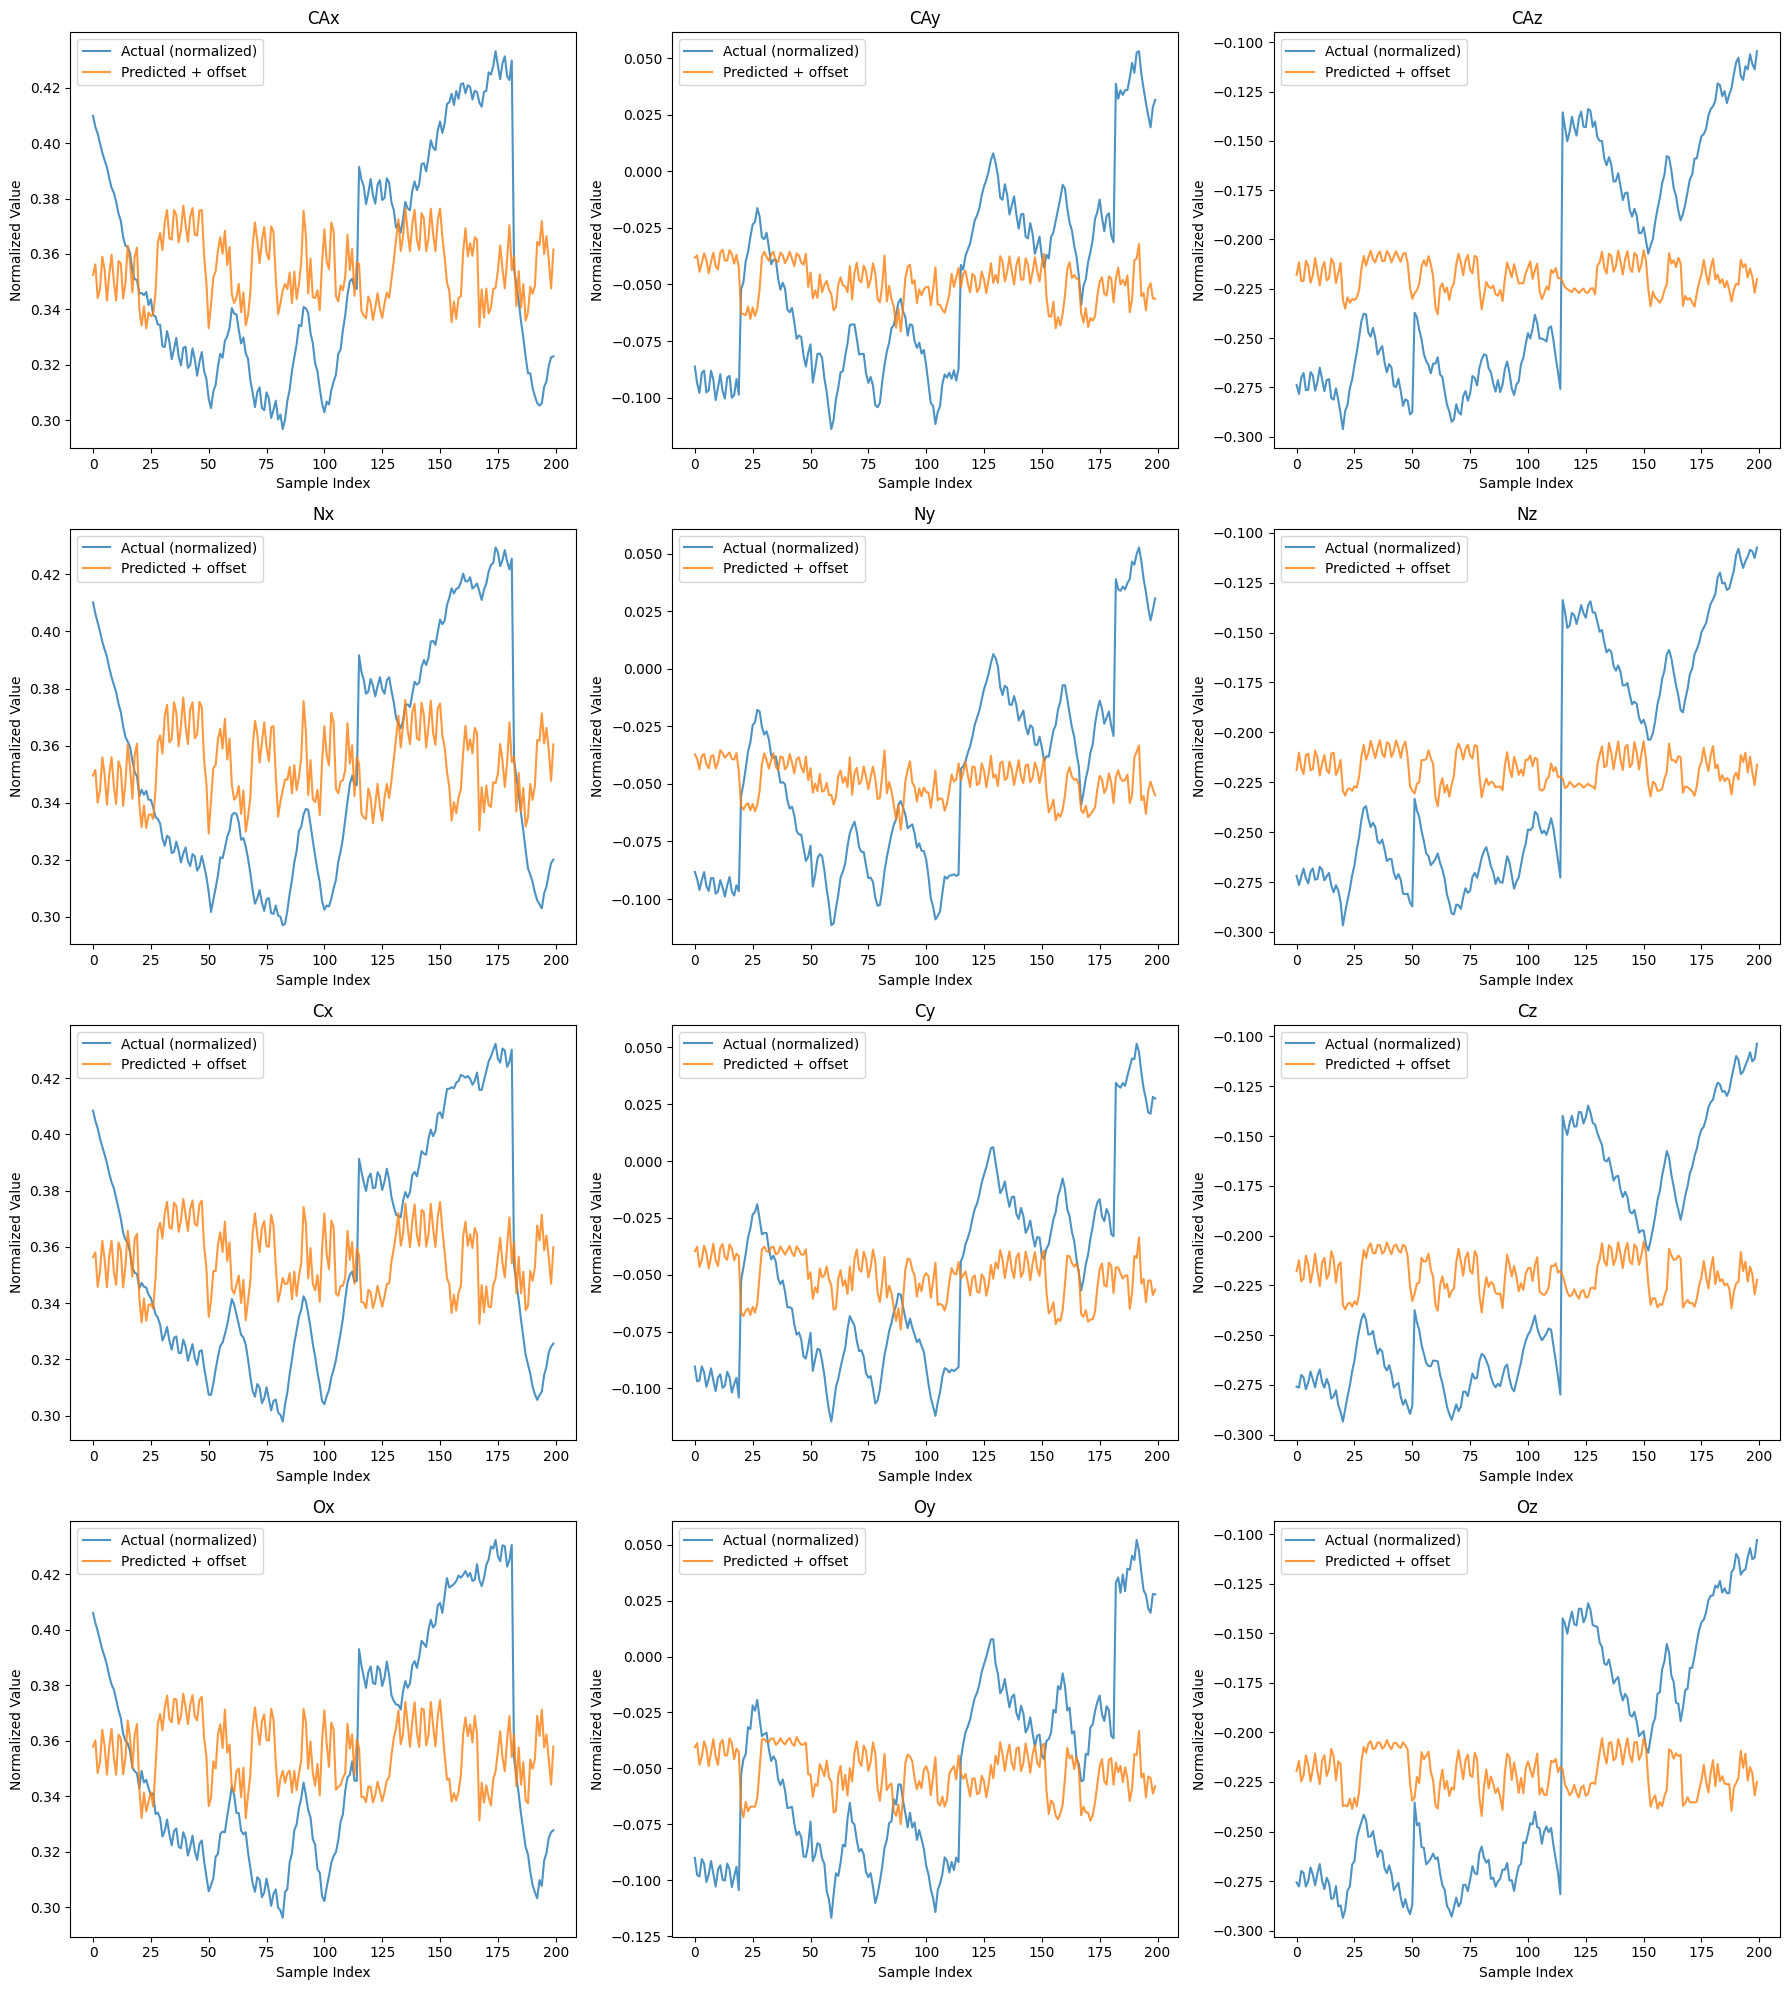

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Predict normalized output
y_pred_norm = model.predict(x_train)

# 2. Limit to first 200 samples
y_pred_200 = y_pred_norm[:200]
y_train_200 = y_train[:200]

# 3. Compute per-target offsets
offsets = np.mean(y_train_200, axis=0) - np.mean(y_pred_200, axis=0)

# 4. Apply the shift
y_pred_shifted = y_pred_200 + offsets

# 5. Plot
target_columns = ["CAx", "CAy", "CAz",
                  "Nx", "Ny", "Nz",
                  "Cx", "Cy", "Cz",
                  "Ox", "Oy", "Oz"]

plt.figure(figsize=(18, 20))

for i in range(12):
    plt.subplot(4, 3, i + 1)
    plt.plot(y_train_200[:, i], label="Actual (normalized)", alpha=0.8)
    plt.plot(y_pred_shifted[:, i], label="Predicted + offset", alpha=0.8)
    plt.title(target_columns[i])
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Value")
    plt.legend()

plt.tight_layout()
plt.show()